# Conjunto de Datos de Predicción del Clima

Este conjunto de datos fue creado con fines de enseñanza y entrenamiento en aprendizaje automático y aprendizaje profundo.  
Se puede utilizar para tareas de clasificación, regresión y pronóstico.  
Es lo suficientemente complejo para demostrar problemas realistas como sobreajuste y datos desbalanceados, manteniendo una estructura intuitiva y accesible.  

## **Origen de los Datos**  

Los datos originales fueron tomados de:

**EUROPEAN CLIMATE ASSESSMENT & DATASET (ECA&D)**, archivo creado el 22-04-2021.  
Estos datos pueden utilizarse libremente siempre que se reconozca la siguiente fuente:  

*Klein Tank, A.M.G. y coautores, 2002. Conjunto de datos diarios de temperatura del aire en superficie y series de precipitación del siglo XX para la Evaluación Climática Europea.*  
*International Journal of Climatology, 22, 1441-1453.*  
**Datos y metadatos disponibles en:** [http://www.ecad.eu](http://www.ecad.eu)  

---

## **Selección y Procesamiento de los Datos**  

Los datos meteorológicos iniciales fueron obtenidos del proyecto ECA&D [1], que proporciona observaciones diarias de estaciones meteorológicas en Europa y el Mediterráneo. Se seleccionaron 18 ciudades o localidades europeas con múltiples observaciones diarias disponibles entre los años 2000 y 2010:

- **Suiza:** Basel  
- **Hungría:** Budapest  
- **Alemania:** Dresden, Düsseldorf, Kassel, München  
- **Países Bajos:** De Bilt, Maastricht  
- **Reino Unido:** Heathrow  
- **Eslovenia:** Ljubljana  
- **Suecia:** Malmo, Estocolmo  
- **Francia:** Montélimar, Perpignan, Tours  
- **Noruega:** Oslo  
- **Italia:** Roma  
- **Austria:** Sonnblick  

Las observaciones meteorológicas diarias para estas 18 localidades abarcan diferentes períodos. Algunas incluyen registros desde el siglo XIX, pero para este conjunto de datos solo se consideraron registros entre **2000 y 2010**, resultando en **3654 observaciones diarias**.  

El conjunto de datos incluye múltiples variables:  

- Todas las localidades contienen registros de **temperatura media, temperatura máxima y temperatura mínima**.  
- Se incluyen otras variables como **cobertura nubosa, velocidad del viento, ráfagas de viento, humedad, presión, radiación global, precipitación y horas de sol**, siempre que los datos estuvieran disponibles.  

### **Limpieza y Transformación de Datos**  

1. Se eliminaron columnas con más del **5% de valores inválidos** ("-9999").  
2. Para columnas con hasta **5% de valores inválidos**, los valores faltantes fueron reemplazados por el valor promedio.  
3. El resultado final incluye **165 variables** a lo largo de **3654 días**.  
4. Se realizaron transformaciones de unidades para normalizar los rangos de valores, facilitando su uso en modelos de aprendizaje automático.  

A pesar de estas transformaciones, se decidió **no estandarizar completamente los datos** para mantener la interpretación intuitiva de las unidades.  

Las unidades finales son:  
- **Temperatura**: grados Celsius  
- **Velocidad del viento y ráfagas**: metros por segundo (m/s)  
- **Humedad**: fracción de 100%  
- **Presión**: 1000 hPa  
- **Radiación global**: 100 W/m²  
- **Precipitación**: centímetros  
- **Horas de sol**: horas  

---

## **Unidades Físicas de las Variables**  

| Código | Descripción | Unidad Original | Unidad Convertida |
|--------|------------|-----------------|------------------|
| CC     | Cobertura nubosa | oktas | oktas |
| DD     | Dirección del viento | grados | grados |
| FG     | Velocidad del viento | 0.1 m/s | 1 m/s |
| FX     | Ráfaga de viento | 0.1 m/s | 1 m/s |
| HU     | Humedad | 1% | fracción de 100% |
| PP     | Presión a nivel del mar | 0.1 hPa | 1000 hPa |
| QQ     | Radiación global | W/m² | 100 W/m² |
| RR     | Precipitación | 0.1 mm |  mm |
| SS     | Horas de sol | 0.1 horas | 1 hora |
| TG     | Temperatura media | 0.1 °C | °C |
| TN     | Temperatura mínima | 0.1 °C | °C |
| TX     | Temperatura máxima | 0.1 °C | °C |

---


Este ejemplo es similar al visto en clase sobre el índice de GINI. Sin embargo, en aquella ocasión, se trabajó con variables categóricas. 

In [2958]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pandas as pd
import numpy as np

# Importar las bibliotecas necesarias
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeClassifier


In [2959]:
df = pd.read_csv("weather_prediction_dataset.csv", encoding='ISO-8859-1')

df

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,20091228,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,...,-2.7,2.4,3.7,0.95,1.0011,0.22,1.50,6.2,1.8,10.6
3650,20091229,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,...,-9.5,0.8,5.3,0.89,0.9966,0.24,0.40,10.4,6.2,14.5
3651,20091230,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,...,-12.5,-7.4,3.8,0.88,0.9939,0.24,1.00,10.0,8.7,11.3
3652,20091231,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,...,-9.3,-6.5,4.2,0.88,0.9933,0.58,0.02,8.5,6.2,10.9


In [2960]:
# Ver las columnas del dataset
print(df.columns)

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'STOCKHOLM_temp_min', 'STOCKHOLM_temp_max', 'TOURS_wind_speed',
       'TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation',
       'TOURS_precipitation', 'TOURS_temp_mean', 'TOURS_temp_min',
       'TOURS_temp_max'],
      dtype='object', length=165)


In [2961]:
print(len(df.columns))  # Muestra cuántas columnas tiene el DataFrame


165


In [2962]:
print(df.columns.tolist())  # Convierte el índice de columnas en una lista


['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max', 'BUDAPEST_cloud_cover', 'BUDAPEST_humidity', 'BUDAPEST_pressure', 'BUDAPEST_global_radiation', 'BUDAPEST_precipitation', 'BUDAPEST_sunshine', 'BUDAPEST_temp_mean', 'BUDAPEST_temp_max', 'DE_BILT_cloud_cover', 'DE_BILT_wind_speed', 'DE_BILT_wind_gust', 'DE_BILT_humidity', 'DE_BILT_pressure', 'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine', 'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max', 'DRESDEN_cloud_cover', 'DRESDEN_wind_speed', 'DRESDEN_wind_gust', 'DRESDEN_humidity', 'DRESDEN_global_radiation', 'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean', 'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover', 'DUSSELDORF_wind_speed', 'DUSSELDORF_wind_gust', 'DUSSELDORF_humidity', 'DUSSELDORF_pressure', 'DUSSELDORF_global_radiation', 'DUSSE

In [2963]:

# Cargar el dataset (reemplaza 'weather_prediction_dataset.csv' con tu archivo real)
df = pd.read_csv("weather_prediction_dataset.csv", encoding='ISO-8859-1')

# Crear diccionarios de DataFrames por cada ubicación
locations = {
    "Basel": df[["DATE", "MONTH", "BASEL_cloud_cover", "BASEL_humidity", "BASEL_pressure", "BASEL_global_radiation", "BASEL_precipitation", "BASEL_sunshine", "BASEL_temp_mean", "BASEL_temp_min", "BASEL_temp_max"]],
    "Budapest": df[["DATE", "MONTH", "BUDAPEST_cloud_cover", "BUDAPEST_humidity", "BUDAPEST_pressure", "BUDAPEST_global_radiation", "BUDAPEST_precipitation", "BUDAPEST_sunshine", "BUDAPEST_temp_mean", "BUDAPEST_temp_max"]],
    "Dresden": df[["DATE", "MONTH", "DRESDEN_cloud_cover", "DRESDEN_wind_speed", "DRESDEN_wind_gust", "DRESDEN_humidity", "DRESDEN_global_radiation", "DRESDEN_precipitation", "DRESDEN_sunshine", "DRESDEN_temp_mean", "DRESDEN_temp_min", "DRESDEN_temp_max"]],
    "Düsseldorf": df[["DATE", "MONTH", "DUSSELDORF_cloud_cover", "DUSSELDORF_wind_speed", "DUSSELDORF_wind_gust", "DUSSELDORF_humidity", "DUSSELDORF_pressure", "DUSSELDORF_global_radiation", "DUSSELDORF_precipitation", "DUSSELDORF_sunshine", "DUSSELDORF_temp_mean", "DUSSELDORF_temp_min", "DUSSELDORF_temp_max"]],
    "Kassel": df[["DATE", "MONTH", "KASSEL_wind_speed", "KASSEL_wind_gust", "KASSEL_humidity", "KASSEL_pressure", "KASSEL_global_radiation", "KASSEL_precipitation", "KASSEL_sunshine", "KASSEL_temp_mean", "KASSEL_temp_min", "KASSEL_temp_max"]],
    "München": df[["DATE", "MONTH", "MUENCHEN_cloud_cover", "MUENCHEN_wind_speed", "MUENCHEN_wind_gust", "MUENCHEN_humidity", "MUENCHEN_pressure", "MUENCHEN_global_radiation", "MUENCHEN_precipitation", "MUENCHEN_sunshine", "MUENCHEN_temp_mean", "MUENCHEN_temp_min", "MUENCHEN_temp_max"]],
    "De Bilt": df[["DATE", "MONTH", "DE_BILT_cloud_cover", "DE_BILT_wind_speed", "DE_BILT_wind_gust", "DE_BILT_humidity", "DE_BILT_pressure", "DE_BILT_global_radiation", "DE_BILT_precipitation", "DE_BILT_sunshine", "DE_BILT_temp_mean", "DE_BILT_temp_min", "DE_BILT_temp_max"]],
    "Maastricht": df[["DATE", "MONTH", "MAASTRICHT_cloud_cover", "MAASTRICHT_wind_speed", "MAASTRICHT_wind_gust", "MAASTRICHT_humidity", "MAASTRICHT_pressure", "MAASTRICHT_global_radiation", "MAASTRICHT_precipitation", "MAASTRICHT_sunshine", "MAASTRICHT_temp_mean", "MAASTRICHT_temp_min", "MAASTRICHT_temp_max"]],
    "Heathrow": df[["DATE", "MONTH", "HEATHROW_cloud_cover", "HEATHROW_humidity", "HEATHROW_pressure", "HEATHROW_global_radiation", "HEATHROW_precipitation", "HEATHROW_sunshine", "HEATHROW_temp_mean", "HEATHROW_temp_min", "HEATHROW_temp_max"]],
    "Ljubljana": df[["DATE", "MONTH", "LJUBLJANA_cloud_cover", "LJUBLJANA_wind_speed", "LJUBLJANA_humidity", "LJUBLJANA_pressure", "LJUBLJANA_global_radiation", "LJUBLJANA_precipitation", "LJUBLJANA_sunshine", "LJUBLJANA_temp_mean", "LJUBLJANA_temp_min", "LJUBLJANA_temp_max"]],
    "Malmo": df[["DATE", "MONTH", "MALMO_wind_speed", "MALMO_precipitation", "MALMO_temp_mean", "MALMO_temp_min", "MALMO_temp_max"]],
    "Estocolmo": df[["DATE", "MONTH", "STOCKHOLM_cloud_cover", "STOCKHOLM_pressure", "STOCKHOLM_precipitation", "STOCKHOLM_sunshine", "STOCKHOLM_temp_mean", "STOCKHOLM_temp_min", "STOCKHOLM_temp_max"]],
    "Montélimar": df[["DATE", "MONTH", "MONTELIMAR_wind_speed", "MONTELIMAR_humidity", "MONTELIMAR_pressure", "MONTELIMAR_global_radiation", "MONTELIMAR_precipitation", "MONTELIMAR_temp_mean", "MONTELIMAR_temp_min", "MONTELIMAR_temp_max"]],
    "Perpignan": df[["DATE", "MONTH", "PERPIGNAN_wind_speed", "PERPIGNAN_humidity", "PERPIGNAN_pressure", "PERPIGNAN_global_radiation", "PERPIGNAN_precipitation", "PERPIGNAN_temp_mean", "PERPIGNAN_temp_min", "PERPIGNAN_temp_max"]],
    "Tours": df[["DATE", "MONTH", "TOURS_wind_speed", "TOURS_humidity", "TOURS_pressure", "TOURS_global_radiation", "TOURS_precipitation", "TOURS_temp_mean", "TOURS_temp_min", "TOURS_temp_max"]],
    "Oslo": df[["DATE", "MONTH", "OSLO_cloud_cover", "OSLO_wind_speed", "OSLO_wind_gust", "OSLO_humidity", "OSLO_pressure", "OSLO_global_radiation", "OSLO_precipitation", "OSLO_sunshine", "OSLO_temp_mean", "OSLO_temp_min", "OSLO_temp_max"]],
    "Roma": df[["DATE", "MONTH", "ROMA_cloud_cover", "ROMA_humidity", "ROMA_pressure", "ROMA_global_radiation", "ROMA_sunshine", "ROMA_temp_mean", "ROMA_temp_min", "ROMA_temp_max"]],
    "Sonnblick": df[["DATE", "MONTH", "SONNBLICK_cloud_cover", "SONNBLICK_humidity", "SONNBLICK_global_radiation", "SONNBLICK_precipitation", "SONNBLICK_sunshine", "SONNBLICK_temp_mean", "SONNBLICK_temp_min", "SONNBLICK_temp_max"]],
}

# Mostrar un ejemplo
##for location, df_location in locations.items():
  ##  print(f"\n{location} DataFrame:")
    ## print(df_location.head())


In [2964]:
df_basel = locations["Basel"]
df_budapest = locations["Budapest"]
df_dresden = locations["Dresden"]
df_Düsseldorf = locations["Düsseldorf"]
df_Kassel = locations["Kassel"]
df_München = locations["München"]
df_DeBilt = locations["De Bilt"]
df_Maastricht = locations["Maastricht"]
df_Heathrow = locations["Heathrow"]
df_Ljubljana = locations["Ljubljana"]
df_Malmo = locations["Malmo"]
df_Estocolmo = locations["Estocolmo"]
df_Montélimar = locations["Montélimar"]
df_Perpignan = locations["Perpignan"]
df_Tours = locations["Tours"]
df_Oslo = locations["Oslo"]
df_Roma = locations["Roma"]
df_Sonnblick = locations["Sonnblick"]


print(df_basel)

          DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
0     20000101      1                  8            0.89          1.0286   
1     20000102      1                  8            0.87          1.0318   
2     20000103      1                  5            0.81          1.0314   
3     20000104      1                  7            0.79          1.0262   
4     20000105      1                  5            0.90          1.0246   
...        ...    ...                ...             ...             ...   
3649  20091228     12                  7            0.82          1.0084   
3650  20091229     12                  7            0.92          1.0028   
3651  20091230     12                  8            0.92          0.9979   
3652  20091231     12                  7            0.93          0.9958   
3653  20100101      1                  8            0.93          0.9965   

      BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
0                 

In [2965]:
# Lista de DataFrames
dataframes = [
    df_basel, df_budapest, df_dresden, df_Düsseldorf, df_Kassel, df_München,
    df_DeBilt, df_Maastricht, df_Heathrow, df_Ljubljana, df_Malmo, df_Estocolmo,
    df_Montélimar, df_Perpignan, df_Tours, df_Oslo, df_Roma, df_Sonnblick
]

# Comprobar si hay valores nulos en los DataFrames
for i, df in enumerate(dataframes):
    if df.isnull().values.any():
        print(f"DataFrame {i+1} tiene valores nulos.")
    else:
        print(f"DataFrame {i+1} no tiene valores nulos.")



DataFrame 1 no tiene valores nulos.
DataFrame 2 no tiene valores nulos.
DataFrame 3 no tiene valores nulos.
DataFrame 4 no tiene valores nulos.
DataFrame 5 no tiene valores nulos.
DataFrame 6 no tiene valores nulos.
DataFrame 7 no tiene valores nulos.
DataFrame 8 no tiene valores nulos.
DataFrame 9 no tiene valores nulos.
DataFrame 10 no tiene valores nulos.
DataFrame 11 no tiene valores nulos.
DataFrame 12 no tiene valores nulos.
DataFrame 13 no tiene valores nulos.
DataFrame 14 no tiene valores nulos.
DataFrame 15 no tiene valores nulos.
DataFrame 16 no tiene valores nulos.
DataFrame 17 no tiene valores nulos.
DataFrame 18 no tiene valores nulos.


El método `df.isnull().values.any()` se utiliza para comprobar si hay valores nulos (NaN o None) en un DataFrame de pandas. Aquí te explico en detalle lo que hace cada parte:

1. **`df.isnull()`**:
   Este método devuelve un DataFrame del mismo tamaño que `df`, pero con valores booleanos (True o False). Cada celda será `True` si el valor correspondiente en el DataFrame original es nulo (NaN o `None`), y `False` si no lo es.

2. **`df.isnull().values`**:
   La propiedad `.values` devuelve un array de NumPy que contiene los valores booleanos resultantes de `isnull()`. Es un array bidimensional (matriz) con `True` en las posiciones de los valores nulos y `False` en las demás.

3. **`df.isnull().values.any()`**:
   Finalmente, el método `.any()` se aplica al array de valores booleanos. Este método devuelve `True` si **al menos uno** de los valores en el array es `True` (es decir, si hay al menos un valor nulo en el DataFrame). Si no hay valores nulos, devuelve `False`.




In [2966]:
# Diccionario de DataFrames con sus nombres
dataframes_dict = {
    "Basel": df_basel,
    "Budapest": df_budapest,
    "Dresden": df_dresden,
    "Düsseldorf": df_Düsseldorf,
    "Kassel": df_Kassel,
    "München": df_München,
    "De Bilt": df_DeBilt,
    "Maastricht": df_Maastricht,
    "Heathrow": df_Heathrow,
    "Ljubljana": df_Ljubljana,
    "Malmo": df_Malmo,
    "Estocolmo": df_Estocolmo,
    "Montélimar": df_Montélimar,
    "Perpignan": df_Perpignan,
    "Tours": df_Tours,
    "Oslo": df_Oslo,
    "Roma": df_Roma,
    "Sonnblick": df_Sonnblick
}

# Mostrar el nombre del DataFrame y la cantidad de columnas
for name, df in dataframes_dict.items():
    num_columns = df.shape[1]  # Obtener el número de columnas
    print(f"El DataFrame {name} tiene {num_columns} columnas.")


El DataFrame Basel tiene 11 columnas.
El DataFrame Budapest tiene 10 columnas.
El DataFrame Dresden tiene 12 columnas.
El DataFrame Düsseldorf tiene 13 columnas.
El DataFrame Kassel tiene 12 columnas.
El DataFrame München tiene 13 columnas.
El DataFrame De Bilt tiene 13 columnas.
El DataFrame Maastricht tiene 13 columnas.
El DataFrame Heathrow tiene 11 columnas.
El DataFrame Ljubljana tiene 12 columnas.
El DataFrame Malmo tiene 7 columnas.
El DataFrame Estocolmo tiene 9 columnas.
El DataFrame Montélimar tiene 10 columnas.
El DataFrame Perpignan tiene 10 columnas.
El DataFrame Tours tiene 10 columnas.
El DataFrame Oslo tiene 13 columnas.
El DataFrame Roma tiene 10 columnas.
El DataFrame Sonnblick tiene 10 columnas.


In [2967]:
# Mostrar el nombre del DataFrame y sus columnas
for name, df in dataframes_dict.items():
    columns = df.columns  # Obtener las columnas
    print(f"Las columnas del DataFrame {name} son: {', '.join(columns)}")


Las columnas del DataFrame Basel son: DATE, MONTH, BASEL_cloud_cover, BASEL_humidity, BASEL_pressure, BASEL_global_radiation, BASEL_precipitation, BASEL_sunshine, BASEL_temp_mean, BASEL_temp_min, BASEL_temp_max
Las columnas del DataFrame Budapest son: DATE, MONTH, BUDAPEST_cloud_cover, BUDAPEST_humidity, BUDAPEST_pressure, BUDAPEST_global_radiation, BUDAPEST_precipitation, BUDAPEST_sunshine, BUDAPEST_temp_mean, BUDAPEST_temp_max
Las columnas del DataFrame Dresden son: DATE, MONTH, DRESDEN_cloud_cover, DRESDEN_wind_speed, DRESDEN_wind_gust, DRESDEN_humidity, DRESDEN_global_radiation, DRESDEN_precipitation, DRESDEN_sunshine, DRESDEN_temp_mean, DRESDEN_temp_min, DRESDEN_temp_max
Las columnas del DataFrame Düsseldorf son: DATE, MONTH, DUSSELDORF_cloud_cover, DUSSELDORF_wind_speed, DUSSELDORF_wind_gust, DUSSELDORF_humidity, DUSSELDORF_pressure, DUSSELDORF_global_radiation, DUSSELDORF_precipitation, DUSSELDORF_sunshine, DUSSELDORF_temp_mean, DUSSELDORF_temp_min, DUSSELDORF_temp_max
Las colum

| DataFrame        | Columnas                                                                                                                                 |
|------------------|------------------------------------------------------------------------------------------------------------------------------------------|
| Basel            | DATE, MONTH, BASEL_cloud_cover, BASEL_humidity, BASEL_pressure, BASEL_global_radiation, BASEL_precipitation, BASEL_sunshine, BASEL_temp_mean, BASEL_temp_min, BASEL_temp_max |
| Budapest         | DATE, MONTH, BUDAPEST_cloud_cover, BUDAPEST_humidity, BUDAPEST_pressure, BUDAPEST_global_radiation, BUDAPEST_precipitation, BUDAPEST_sunshine, BUDAPEST_temp_mean, BUDAPEST_temp_max |
| Dresden          | DATE, MONTH, DRESDEN_cloud_cover, DRESDEN_wind_speed, DRESDEN_wind_gust, DRESDEN_humidity, DRESDEN_global_radiation, DRESDEN_precipitation, DRESDEN_sunshine, DRESDEN_temp_mean, DRESDEN_temp_min, DRESDEN_temp_max |
| Düsseldorf       | DATE, MONTH, DUSSELDORF_cloud_cover, DUSSELDORF_wind_speed, DUSSELDORF_wind_gust, DUSSELDORF_humidity, DUSSELDORF_pressure, DUSSELDORF_global_radiation, DUSSELDORF_precipitation, DUSSELDORF_sunshine, DUSSELDORF_temp_mean, DUSSELDORF_temp_min, DUSSELDORF_temp_max |
| Kassel           | DATE, MONTH, KASSEL_wind_speed, KASSEL_wind_gust, KASSEL_humidity, KASSEL_pressure, KASSEL_global_radiation, KASSEL_precipitation, KASSEL_sunshine, KASSEL_temp_mean, KASSEL_temp_min, KASSEL_temp_max |
| München          | DATE, MONTH, MUENCHEN_cloud_cover, MUENCHEN_wind_speed, MUENCHEN_wind_gust, MUENCHEN_humidity, MUENCHEN_pressure, MUENCHEN_global_radiation, MUENCHEN_precipitation, MUENCHEN_sunshine, MUENCHEN_temp_mean, MUENCHEN_temp_min, MUENCHEN_temp_max |
| De Bilt          | DATE, MONTH, DE_BILT_cloud_cover, DE_BILT_wind_speed, DE_BILT_wind_gust, DE_BILT_humidity, DE_BILT_pressure, DE_BILT_global_radiation, DE_BILT_precipitation, DE_BILT_sunshine, DE_BILT_temp_mean, DE_BILT_temp_min, DE_BILT_temp_max |
| Maastricht       | DATE, MONTH, MAASTRICHT_cloud_cover, MAASTRICHT_wind_speed, MAASTRICHT_wind_gust, MAASTRICHT_humidity, MAASTRICHT_pressure, MAASTRICHT_global_radiation, MAASTRICHT_precipitation, MAASTRICHT_sunshine, MAASTRICHT_temp_mean, MAASTRICHT_temp_min, MAASTRICHT_temp_max |
| Heathrow         | DATE, MONTH, HEATHROW_cloud_cover, HEATHROW_humidity, HEATHROW_pressure, HEATHROW_global_radiation, HEATHROW_precipitation, HEATHROW_sunshine, HEATHROW_temp_mean, HEATHROW_temp_min, HEATHROW_temp_max |
| Ljubljana        | DATE, MONTH, LJUBLJANA_cloud_cover, LJUBLJANA_wind_speed, LJUBLJANA_humidity, LJUBLJANA_pressure, LJUBLJANA_global_radiation, LJUBLJANA_precipitation, LJUBLJANA_sunshine, LJUBLJANA_temp_mean, LJUBLJANA_temp_min, LJUBLJANA_temp_max |
| Malmo            | DATE, MONTH, MALMO_wind_speed, MALMO_precipitation, MALMO_temp_mean, MALMO_temp_min, MALMO_temp_max |
| Estocolmo        | DATE, MONTH, STOCKHOLM_cloud_cover, STOCKHOLM_pressure, STOCKHOLM_precipitation, STOCKHOLM_sunshine, STOCKHOLM_temp_mean, STOCKHOLM_temp_min, STOCKHOLM_temp_max |
| Montélimar       | DATE, MONTH, MONTELIMAR_wind_speed, MONTELIMAR_humidity, MONTELIMAR_pressure, MONTELIMAR_global_radiation, MONTELIMAR_precipitation, MONTELIMAR_temp_mean, MONTELIMAR_temp_min, MONTELIMAR_temp_max |
| Perpignan        | DATE, MONTH, PERPIGNAN_wind_speed, PERPIGNAN_humidity, PERPIGNAN_pressure, PERPIGNAN_global_radiation, PERPIGNAN_precipitation, PERPIGNAN_temp_mean, PERPIGNAN_temp_min, PERPIGNAN_temp_max |
| Tours            | DATE, MONTH, TOURS_wind_speed, TOURS_humidity, TOURS_pressure, TOURS_global_radiation, TOURS_precipitation, TOURS_temp_mean, TOURS_temp_min, TOURS_temp_max |
| Oslo             | DATE, MONTH, OSLO_cloud_cover, OSLO_wind_speed, OSLO_wind_gust, OSLO_humidity, OSLO_pressure, OSLO_global_radiation, OSLO_precipitation, OSLO_sunshine, OSLO_temp_mean, OSLO_temp_min, OSLO_temp_max |
| Roma             | DATE, MONTH, ROMA_cloud_cover, ROMA_humidity, ROMA_pressure, ROMA_global_radiation, ROMA_sunshine, ROMA_temp_mean, ROMA_temp_min, ROMA_temp_max |
| Sonnblick        | DATE, MONTH, SONNBLICK_cloud_cover, SONNBLICK_humidity, SONNBLICK_global_radiation, SONNBLICK_precipitation, SONNBLICK_sunshine, SONNBLICK_temp_mean, SONNBLICK_temp_min, SONNBLICK_temp_max |


In [2968]:
# Renombrar las columnas de los DataFrames eliminando el prefijo del nombre de la ciudad
def clean_column_names(df):
    # Iterar sobre las columnas y eliminar el prefijo (si lo tiene)
    df.columns = [col.split('_', 1)[-1] if '_' in col else col for col in df.columns]
    return df

# Aplicar la limpieza de columnas a cada DataFrame
df_basel = clean_column_names(df_basel)
df_budapest = clean_column_names(df_budapest)
df_dresden = clean_column_names(df_dresden)
df_Düsseldorf = clean_column_names(df_Düsseldorf)
df_Kassel = clean_column_names(df_Kassel)
df_München = clean_column_names(df_München)
df_DeBilt = clean_column_names(df_DeBilt)
df_Maastricht = clean_column_names(df_Maastricht)
df_Heathrow = clean_column_names(df_Heathrow)
df_Ljubljana = clean_column_names(df_Ljubljana)
df_Malmo = clean_column_names(df_Malmo)
df_Estocolmo = clean_column_names(df_Estocolmo)
df_Montélimar = clean_column_names(df_Montélimar)
df_Perpignan = clean_column_names(df_Perpignan)
df_Tours = clean_column_names(df_Tours)
df_Oslo = clean_column_names(df_Oslo)
df_Roma = clean_column_names(df_Roma)
df_Sonnblick = clean_column_names(df_Sonnblick)

# Verificar las nuevas columnas
print(df_basel.columns)


Index(['DATE', 'MONTH', 'cloud_cover', 'humidity', 'pressure',
       'global_radiation', 'precipitation', 'sunshine', 'temp_mean',
       'temp_min', 'temp_max'],
      dtype='object')


In [2969]:
print(df_Roma)

          DATE  MONTH  cloud_cover  humidity  pressure  global_radiation  \
0     20000101      1            0      0.72    1.0244              0.92   
1     20000102      1            2      0.74    1.0263              0.81   
2     20000103      1            0      0.77    1.0288              0.89   
3     20000104      1            1      0.85    1.0273              0.89   
4     20000105      1            2      0.92    1.0238              0.74   
...        ...    ...          ...       ...       ...               ...   
3649  20091228     12            6      0.84    1.0111              0.16   
3650  20091229     12            8      0.86    1.0089              0.17   
3651  20091230     12            6      0.78    1.0071              0.41   
3652  20091231     12            6      0.76    1.0009              0.62   
3653  20100101      1            3      0.73    1.0152              1.56   

      sunshine  temp_mean  temp_min  temp_max  
0          8.4        1.6       3.0    

In [2970]:
# Mostrar el nombre del DataFrame y sus columnas
for name, df in dataframes_dict.items():
    columns = df.columns  # Obtener las columnas
    print(f"Las columnas del DataFrame {name} son: {', '.join(columns)}")

Las columnas del DataFrame Basel son: DATE, MONTH, cloud_cover, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame Budapest son: DATE, MONTH, cloud_cover, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_max
Las columnas del DataFrame Dresden son: DATE, MONTH, cloud_cover, wind_speed, wind_gust, humidity, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame Düsseldorf son: DATE, MONTH, cloud_cover, wind_speed, wind_gust, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame Kassel son: DATE, MONTH, wind_speed, wind_gust, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame München son: DATE, MONTH, cloud_cover, wind_speed, wind_gust, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_

In [2971]:
# Obtener el conjunto de columnas de cada DataFrame
columns_basel = set(df_basel.columns)
columns_budapest = set(df_budapest.columns)
columns_dresden = set(df_dresden.columns)
columns_düsseldorf = set(df_Düsseldorf.columns)
columns_kassel = set(df_Kassel.columns)
columns_münchen = set(df_München.columns)
columns_debilt = set(df_DeBilt.columns)
columns_maastricht = set(df_Maastricht.columns)
columns_heathrow = set(df_Heathrow.columns)
columns_ljubljana = set(df_Ljubljana.columns)
columns_malmo = set(df_Malmo.columns)
columns_estocolmo = set(df_Estocolmo.columns)
columns_montelimar = set(df_Montélimar.columns)
columns_perpignan = set(df_Perpignan.columns)
columns_tours = set(df_Tours.columns)
columns_oslo = set(df_Oslo.columns)
columns_roma = set(df_Roma.columns)
columns_sonnblick = set(df_Sonnblick.columns)

# Obtener la intersección de las columnas en todos los DataFrames
common_columns = columns_basel
for df_columns in [columns_budapest, columns_dresden, columns_düsseldorf, columns_kassel, columns_münchen, 
                   columns_debilt, columns_maastricht, columns_heathrow, columns_ljubljana, columns_malmo, 
                   columns_estocolmo, columns_montelimar, columns_perpignan, columns_tours, columns_oslo, 
                   columns_roma, columns_sonnblick]:
    common_columns &= df_columns

# Ver las columnas comunes
print("Columnas comunes en todos los DataFrames:", common_columns)


Columnas comunes en todos los DataFrames: {'MONTH', 'DATE'}


In [2972]:
# Verificar qué DataFrames tienen la columna 'precipitation'
dataframes_with_precipitation = []

# Lista de DataFrames y sus nombres
dataframes = [
    ("Basel", df_basel),
    ("Budapest", df_budapest),
    ("Dresden", df_dresden),
    ("Düsseldorf", df_Düsseldorf),
    ("Kassel", df_Kassel),
    ("München", df_München),
    ("De Bilt", df_DeBilt),
    ("Maastricht", df_Maastricht),
    ("Heathrow", df_Heathrow),
    ("Ljubljana", df_Ljubljana),
    ("Malmo", df_Malmo),
    ("Estocolmo", df_Estocolmo),
    ("Montélimar", df_Montélimar),
    ("Perpignan", df_Perpignan),
    ("Tours", df_Tours),
    ("Oslo", df_Oslo),
    ("Roma", df_Roma),
    ("Sonnblick", df_Sonnblick)
]

# Comprobar si la columna 'precipitation' está presente en cada DataFrame
for name, df in dataframes:
    if 'precipitation' in df.columns:
        dataframes_with_precipitation.append(name)

# Ver los DataFrames que contienen la columna 'precipitation'
print("Los DataFrames que contienen la columna 'precipitation' son:", dataframes_with_precipitation)

# Verificar qué DataFrames no tienen la columna 'precipitation'
dataframes_without_precipitation = []

# Comprobar si la columna 'precipitation' está ausente en cada DataFrame
for name, df in dataframes:
    if 'precipitation' not in df.columns:
        dataframes_without_precipitation.append(name)

# Ver los DataFrames que no contienen la columna 'precipitation'
print("Los DataFrames que no contienen la columna 'precipitation' son:", dataframes_without_precipitation)



Los DataFrames que contienen la columna 'precipitation' son: ['Basel', 'Budapest', 'Dresden', 'Düsseldorf', 'Kassel', 'München', 'Maastricht', 'Heathrow', 'Ljubljana', 'Malmo', 'Estocolmo', 'Montélimar', 'Perpignan', 'Tours', 'Oslo', 'Sonnblick']
Los DataFrames que no contienen la columna 'precipitation' son: ['De Bilt', 'Roma']


In [2973]:
# Ver el valor más alto de la columna 'precipitation' en el DataFrame Basel
max_precipitation = df_basel['precipitation'].max()
print("El valor más alto de 'precipitation' en Basel es:", max_precipitation)



El valor más alto de 'precipitation' en Basel es: 7.57


In [2974]:
zero_precipitation_basel = (df_basel['precipitation'] == 0.0).sum()
print(zero_precipitation_basel)



1947


In [2975]:

# Verificar cuántas precipitaciones son mayores a 0.0 en Basel
precipitation_greater_than_zero = (df_basel['precipitation'] > 0.0).sum()
precipitation_greater_than_zero

num = np.int64(1707)
print(num)


1707


In [2976]:
num_filas_basel = df_basel.shape[0]
num_filas_basel
# cantidad de filas de basel se observa que 1947 + 1707 = total filas por ende NO hay nulos

3654

In [2977]:
min_fecha_basel = df_basel['DATE'].min()
max_fecha_basel = df_basel['DATE'].max()

(min_fecha_basel, max_fecha_basel)   ## tiempo de muestreo desde 2000 Enero 01 hasta 2010 Enero 01

(20000101, 20100101)

In [2978]:
# Diccionario de DataFrames que contienen la columna 'precipitation'
dataframes_con_precipitacion = {
    'Basel': df_basel,
    'Budapest': df_budapest,
    'Dresden': df_dresden,
    'Düsseldorf': df_Düsseldorf,
    'Kassel': df_Kassel,
    'München': df_München,
    'De Bilt': df_DeBilt,
    'Maastricht': df_Maastricht,
    'Heathrow': df_Heathrow,
    'Ljubljana': df_Ljubljana,
    'Estocolmo': df_Estocolmo,
    'Montélimar': df_Montélimar,
    'Perpignan': df_Perpignan,
    'Tours': df_Tours,
    'Oslo': df_Oslo,
    'Roma': df_Roma,
    'Sonnblick': df_Sonnblick
}

# Encontrar la precipitación más alta en cada DataFrame
max_precipitacion = {}
for ciudad, df in dataframes_con_precipitacion.items():
    if 'precipitation' in df.columns:
        max_precipitacion[ciudad] = df['precipitation'].max()

# Mostrar la precipitación más alta en cada ciudad
max_precipitacion


{'Basel': 7.57,
 'Budapest': 6.96,
 'Dresden': 15.8,
 'Düsseldorf': 5.74,
 'Kassel': 5.42,
 'München': 9.79,
 'Maastricht': 5.87,
 'Heathrow': 3.66,
 'Ljubljana': 8.64,
 'Estocolmo': 4.3,
 'Montélimar': 15.4,
 'Perpignan': 16.04,
 'Tours': 6.2,
 'Oslo': 5.6,
 'Sonnblick': 5.95}

In [2979]:
# Filtrar el DataFrame de Perpignan para encontrar la fila con la precipitación más alta
max_precipitacion_perpignan = df_Perpignan[df_Perpignan['precipitation'] == 16.04]

# Mostrar toda la información sobre ese día
max_precipitacion_perpignan


,DATE,MONTH,wind_speed,humidity,pressure,global_radiation,precipitation,temp_mean,temp_min,temp_max
2144,20051114,11,3.6,0.93,1.014,0.07,16.04,13.5,11.9,15.1


# TEORÍA: Factores relacionados con la Precipitación  ☔☔☔

La **lluvia** es una precipitación de agua líquida en forma de gotas que caen con velocidad apreciable y de modo continuo. Según el tamaño de las gotas se califican de:

- **Llovizna**: Precipitación bastante uniforme compuesta de gotas de agua finas, muy próximas unas a otras, que cae de las nubes. Las gotas de llovizna suelen tener un diámetro menor de 0,5 mm y casi parece que flotan. Se considera cuando la precipitación es muy ligera, con valores de lluvia generalmente entre 0.1 mm y 2 mm por hora. Es una lluvia muy suave y dispersa.
  
- **Lluvia**: Se clasifica como lluvia cuando la precipitación es más intensa, y los valores suelen ser más de 2 mm por hora. Dependiendo de la cantidad, puede ser ligera, moderada o fuerte.

- **Chubasco**: Un chubasco es una precipitación repentina, intensa y de corta duración. Estas precipitaciones pueden ser muy localizadas, afectando áreas relativamente pequeñas.


Estas dos últimas modalidades se clasifican por su intensidad en:

- **Fuertes**: Entre 15 y 30 mm/hora.
- **Muy fuertes**: Entre 30 y 60 mm/hora.
- **Torrenciales**: Por encima de 60 mm/hora.


## Factores que afectan la lluvia

La lluvia depende de tres factores fundamentales:

1. ✅**Presión atmosférica**  
2. ✅**Temperatura**
3. ✅**Humedad atmosférica**


---

Fuente: [Protección Civil - Lluvias Intensas](https://www.proteccioncivil.es/coordinacion/gestion-de-riesgos/meterologicos/lluvias-intensas#:~:text=La%20lluvia%20depende%20de%20tres,temperatura%20y%20la%20humedad%20atmosf%C3%A9rica.)


### 📊 DataFrame con más columnas

Los DataFrames con más columnas y que incluyen `precipitation` son:

- **Düsseldorf** (13 columnas)  
- **München** (13 columnas)  
- **Oslo** (13 columnas)  


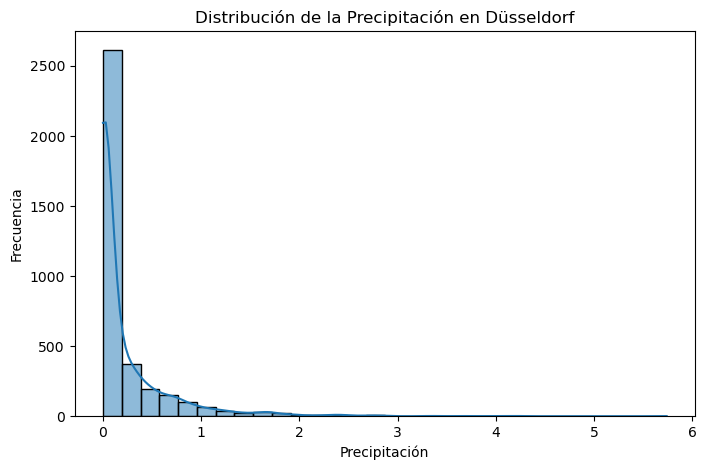

In [2980]:
# Graficar histograma con KDE
plt.figure(figsize=(8, 5))
sns.histplot(df_Düsseldorf["precipitation"], bins=30, kde=True)
plt.xlabel("Precipitación")
plt.ylabel("Frecuencia")
plt.title("Distribución de la Precipitación en Düsseldorf")
plt.show()

In [2981]:
# Contar los valores menores a 0.1
num_menor_a_0_1 = (df_Düsseldorf["precipitation"] < 0.1).sum()

print(f"Cantidad de valores menores a 0.1: {num_menor_a_0_1}")

Cantidad de valores menores a 0.1: 2334


Para clasificar un valor como "no llueve" por lo poco y despreciable, agrego una categoría adicional en la parte inferior de tu clasificación. Esta categoría representaría una precipitación muy baja, que no tiene un impacto significativo.

Podrías definirla como:

Valor de precipitación < 0.1 mm: Considerado como "No llueve" o "Despreciable".

In [2982]:
# Filtrando el DataFrame para obtener solo las filas con precipitación >= 0.1 mm
df_rain_Düsseldorf= df_Düsseldorf[df_Düsseldorf['precipitation'] >= 0.1]

# Ahora df_rain_Düsseldorf contendrá solo los casos donde la precipitación es igual o mayor a 0.1 mm


In [2983]:
# Contar el número de filas en cada DataFrame
df_rain_Düsseldorf_rows = len(df_rain_Düsseldorf)
df_Düsseldorf_rows = len(df_Düsseldorf)

# Mostrar los resultados
print(f'Número de filas en df_rain_Düsseldorf: {df_rain_Düsseldorf_rows}')
print(f'Número de filas en df_Düsseldorf: {df_Düsseldorf_rows}')


Número de filas en df_rain_Düsseldorf: 1320
Número de filas en df_Düsseldorf: 3654


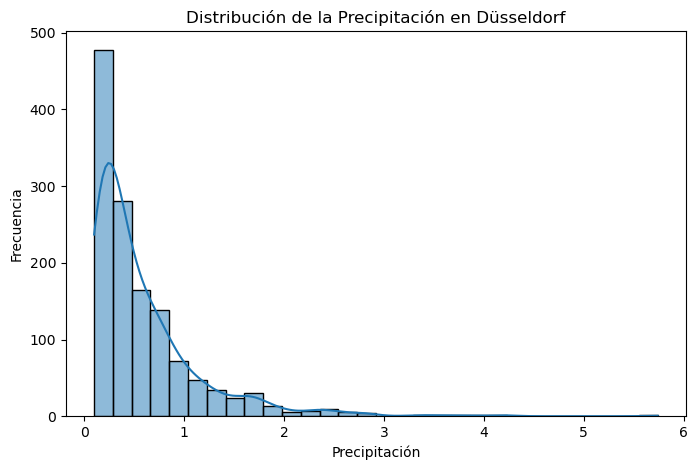

In [2984]:
# Graficar histograma con KDE
plt.figure(figsize=(8, 5))
sns.histplot(df_rain_Düsseldorf["precipitation"], bins=30, kde=True)
plt.xlabel("Precipitación")
plt.ylabel("Frecuencia")
plt.title("Distribución de la Precipitación en Düsseldorf")
plt.show()

In [2985]:
# Función para categorizar la precipitación
def categorize_precipitation(precipitation):
    if precipitation < 0.1:
        return 0  # No llueve , para testear que no se filtro ningun dato que descarte
    elif 0.1 <= precipitation < 0.4:
        return 1  # Llovizna
    elif 0.4 <= precipitation < 1.2:
        return 2  # Lluvia
    elif 1.2 <= precipitation:
        return 3  # Chubasco - Fuertes

# Función para determinar si las condiciones son favorables para caminar
def is_weather_favorable(precipitation):
    if precipitation < 0.4:
        return True  # Condiciones favorables para caminar (llovizna no molesta)
    else:
        return False  # No es favorable para caminar (lluvia o más)

# Filtrar el DataFrame para obtener solo los casos con precipitación >= 0.1 mm y crear una copia
df_rain_Düsseldorf = df_Düsseldorf[df_Düsseldorf['precipitation'] >= 0.1].copy()

# Aplicar la función de categorización a la columna de precipitación en df_rain_Düsseldorf
df_rain_Düsseldorf['precipitation_category'] = df_rain_Düsseldorf['precipitation'].apply(categorize_precipitation)

# Aplicar la función is_weather_favorable para determinar si las condiciones son favorables para caminar
df_rain_Düsseldorf['is_weather_favorable'] = df_rain_Düsseldorf['precipitation'].apply(is_weather_favorable)

# Verificar el resultado
print(df_rain_Düsseldorf[['precipitation', 'precipitation_category', 'is_weather_favorable']].head())


   precipitation  precipitation_category  is_weather_favorable
0           0.22                       1                  True
2           0.28                       1                  True
3           0.97                       2                 False
5           0.18                       1                  True
7           0.12                       1                  True


<Axes: xlabel='precipitation_category', ylabel='count'>

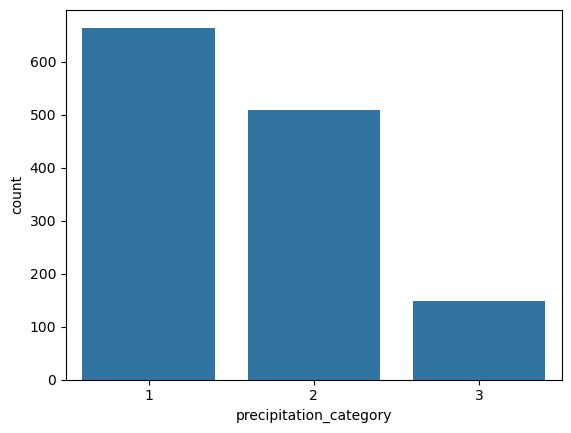

In [2986]:
sns.countplot(x='precipitation_category', data=df_rain_Düsseldorf)

| Categoría Numérica | Descripción                 | Rango de Precipitación (mm) |
|--------------------|----------------------------|-----------------------------|
| 1                 | Llovizna                    | Menos de 0.4 mm            |
| 2                 | Lluvia                      | 0.4 mm a 1.2 mm            |
| 3                 | Chubasco - Fuertes          | 1.2 mm a mayores            |


<Axes: xlabel='is_weather_favorable', ylabel='count'>

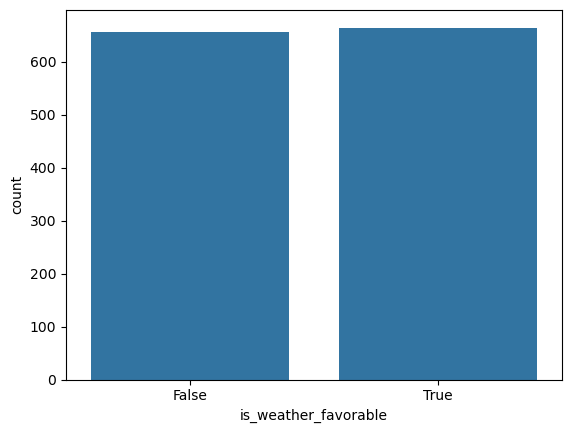

In [2987]:
sns.countplot(x='is_weather_favorable', data=df_rain_Düsseldorf)

In [2988]:
# Contar cuántas filas son buenas para caminar (True) y malas para caminar (False)
walkable_counts = df_rain_Düsseldorf['is_weather_favorable'].value_counts()

# Mostrar el resultado
print(walkable_counts)


is_weather_favorable
True     664
False    656
Name: count, dtype: int64


In [2989]:
print(df_rain_Düsseldorf.shape[1])
print(df_rain_Düsseldorf.columns)



15
Index(['DATE', 'MONTH', 'cloud_cover', 'wind_speed', 'wind_gust', 'humidity',
       'pressure', 'global_radiation', 'precipitation', 'sunshine',
       'temp_mean', 'temp_min', 'temp_max', 'precipitation_category',
       'is_weather_favorable'],
      dtype='object')


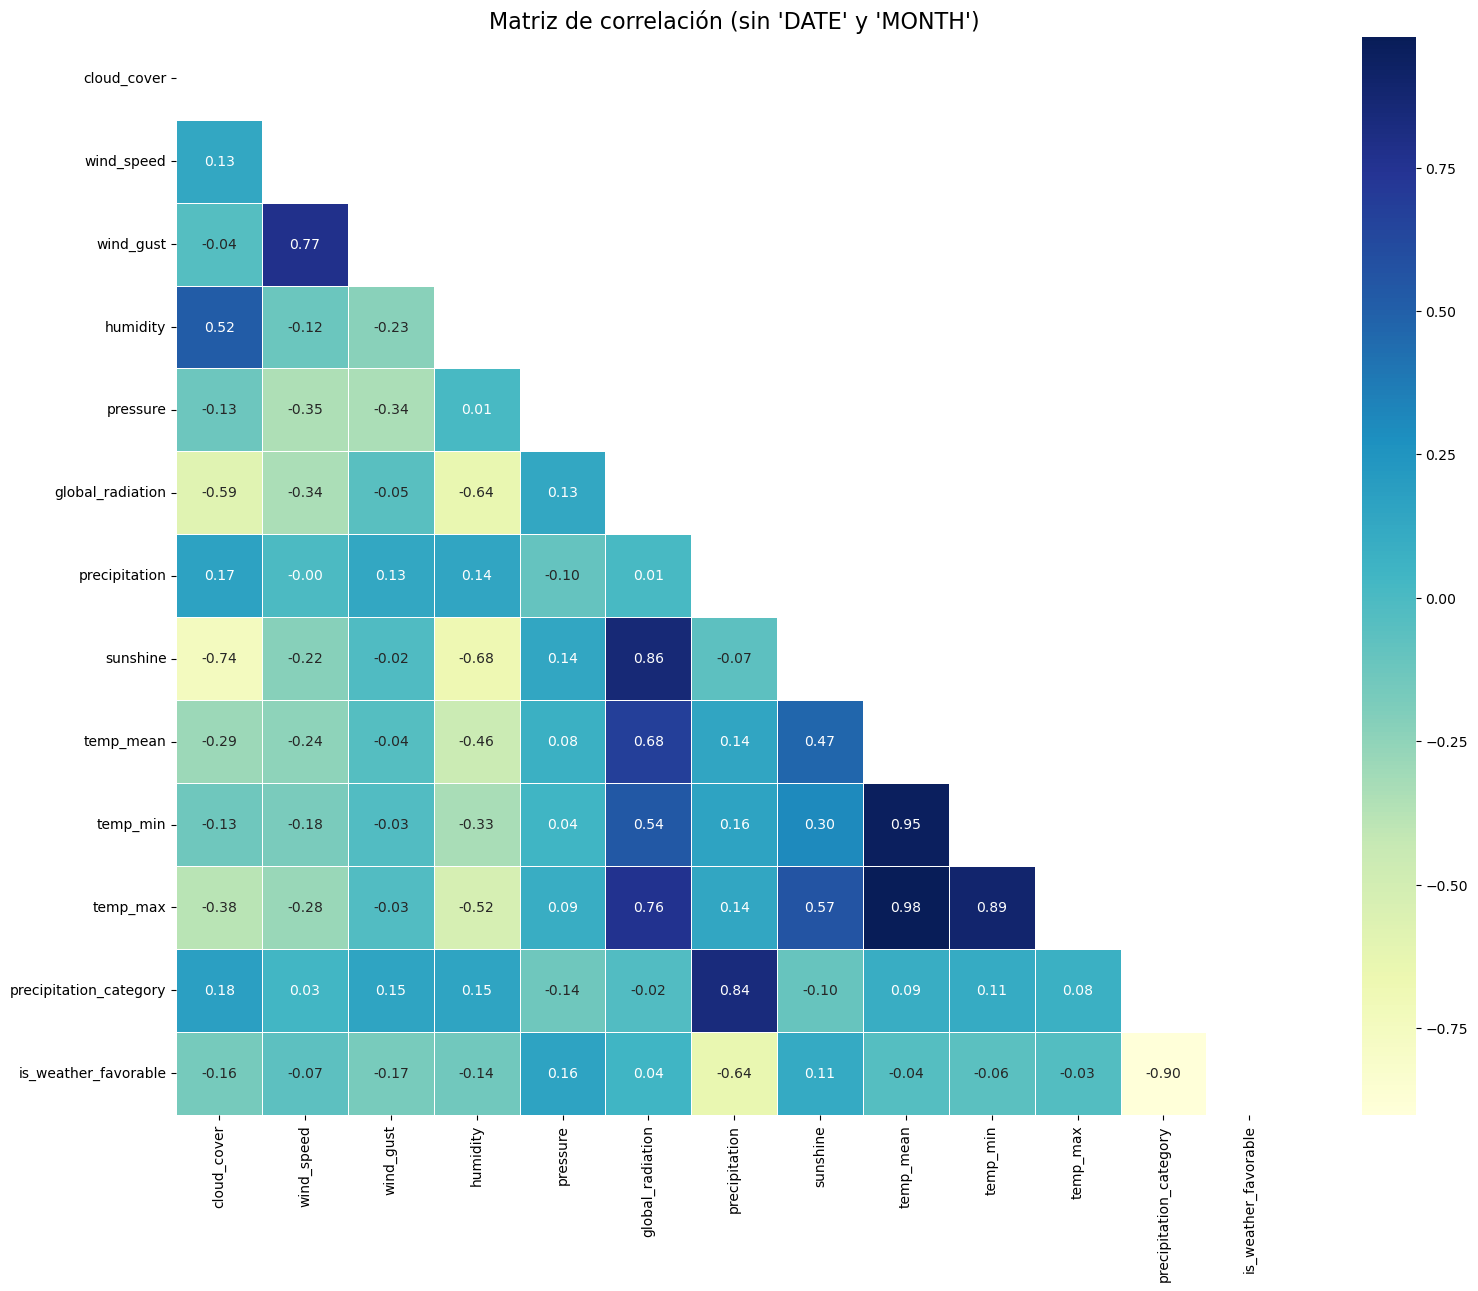

In [2990]:

# Eliminar las columnas "DATE" y "MONTH"
df_filtered = df_rain_Düsseldorf.drop(columns=["DATE", "MONTH"])

# Calcular la matriz de correlación
corr_matrix_filtered = df_filtered.corr()

# Crear una máscara para ocultar la parte superior del triángulo
mask = np.triu(np.ones_like(corr_matrix_filtered, dtype=bool))

# Configurar la figura
fig, ax = plt.subplots(figsize=(18, 14))  # Aumentar tamaño de la figura

# Graficar el heatmap
sns.heatmap(corr_matrix_filtered, cmap="YlGnBu", annot=True, mask=mask, fmt=".2f", linewidths=0.5, ax=ax)

# Configurar título
ax.set_title("Matriz de correlación (sin 'DATE' y 'MONTH')", fontsize=16)

# Mostrar la gráfica
plt.show()


# 🌧️ **Análisis de Correlación con la Precipitación** - Düsseldorf  

## 🔹 **Variables con Alta Correlación a la Precipitación**  

### 📈 **Correlación Positiva**  
- **Humedad (`humidity`) → 0.26**  
  - Mayor humedad = mayor precipitación.  
  - La humedad es clave en la formación de lluvias, lo cual es esperado.  

- **Velocidad del viento (`wind_speed`) → 0.24**  
  - Más viento = más lluvia.  
  - Puede estar asociado a frentes atmosféricos o tormentas.  

- **Ráfagas de viento (`wind_gust`) → 0.35**  
  - Rachas de viento más fuertes = más precipitación.  
  - Se asocia a tormentas o sistemas de baja presión.  

- **Cobertura de nubes (`cloud_cover`) → 0.32**  
  - Más nubosidad = más precipitación.  

---

### 📉 **Correlación Negativa**  
- **Horas de sol (`sunshine`) → -0.27**  
  - Más precipitación = menos sol.  
  - Días lluviosos suelen ser nublados.  

- **Radiación global (`global_radiation`) → -0.16**  
  - Más radiación solar = menos lluvia.  
  - Relación débil pero esperada, ya que más sol implica menos nubes.  

- **Presión atmosférica (`pressure`) → -0.31**  
  - Menor presión = más lluvia.  
  - Baja presión suele estar asociada a sistemas de tormenta.  

---

## 📊 **Conclusión: Variables más relevantes para el modelo de predicción**  

Las dos variables más relevantes para un modelo de predicción de la precipitación son:  

1. **Ráfagas de viento (`wind_gust`) → 0.35**  
   - Presenta la correlación positiva más alta.  
   - Las rachas de viento fuertes están estrechamente asociadas con los eventos de precipitación, ya que suelen indicar tormentas o sistemas de baja presión.  

2. **Presión atmosférica (`pressure`) → -0.31**  
   - Muestra la correlación negativa más significativa.  
   - La baja presión es un indicador confiable de sistemas de tormenta, siendo clave para anticipar la precipitación.  

Ambas variables presentan una fuerte correlación y están respaldadas por fundamentos físicos claros, lo que las convierte en las mejores opciones para un modelo de predicción de la variable `precipitation`.  








Los coeficientes de correlación SON relativamente bajos, lo que sugiere que ninguna variable individual explica de manera fuerte la variabilidad de la precipitación. 

Ahora, selecciono UNICAMENTE 2 de esas variables y estas van a ser las que utilicemos para entrenar el primer modelo.

In [2991]:
X_two = df_rain_Düsseldorf[['wind_gust', 'pressure']].copy()
#X_two = df_rain_Düsseldorf[['wind_gust', 'cloud_cover']].copy() mostrar lo que pasa

In [2992]:
y = df_rain_Düsseldorf.is_weather_favorable

In [2993]:
from sklearn.tree import DecisionTreeRegressor

# Usamos 4 ramas (máxima profundidad = 4) para evitar el sobreajuste
tree_two = DecisionTreeRegressor(max_depth=4)   
tree_two.fit(X_two, y)

#ojo con el evitar problemas como sobreajuste, bajo rendimiento en datos nuevos y sensibilidad a los datos.


DecisionTreeRegressor(max_depth=4)

 Ahora, con nuestro modelo entrenado, generar las predicciones sobre el X que generamos anteriormente:

In [2994]:
y_two_pred = tree_two.predict(X_two)

In [2995]:
y

0        True
2        True
3       False
5        True
7        True
        ...  
3645    False
3646     True
3648    False
3650    False
3651    False
Name: is_weather_favorable, Length: 1320, dtype: bool

In [2996]:
y_two_pred

array([0.6473029 , 0.48192771, 0.48192771, ..., 0.32352941, 0.59411765,
       0.59411765])

redondeo, ya que no sirven datos continuos

In [2997]:
y_two_pred_2 = list(map(round, y_two_pred))


y_two_pred_2

[1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,


In [2998]:
# Supongamos que y y y_two_pred_2 son arrays o listas
unique_y, counts_y = np.unique(y, return_counts=True)
unique_pred, counts_pred = np.unique(y_two_pred_2, return_counts=True)

# Mostrar los resultados
print("Conteo en y:")
for val, count in zip(unique_y, counts_y):
    print(f"Valor {val}: {count} veces")

print("\nConteo en y_two_pred_2:")
for val, count in zip(unique_pred, counts_pred):
    print(f"Valor {val}: {count} veces")


Conteo en y:
Valor False: 656 veces
Valor True: 664 veces

Conteo en y_two_pred_2:
Valor 0: 575 veces
Valor 1: 745 veces


In [2999]:
from sklearn.metrics import accuracy_score

#Comaparamos con las etiquetas reales
accuracy_score(y,y_two_pred_2)

#cuando aumento las hojas aumento esto ojo con el sobreajuste, bajo rendimiento en datos nuevos y sensibilidad a los datos.


0.615909090909091

Ahora, vuelvo a entrenar el modelo, pero utilizando un nuevo X que contenga TODAS las features (salvo las similares).

In [3000]:
X_full = df_rain_Düsseldorf.copy()

X_full.drop(columns=['precipitation', 'precipitation_category', 'is_weather_favorable'], inplace=True)

In [3001]:
tree_full = DecisionTreeClassifier(max_depth=4)
tree_full.fit(X_full, y)
y_pred = tree_full.predict(X_full)
accuracy_score(y, y_pred)

0.6666666666666666

En este caso mejoro, pero este modelo no es muy bueno para este caso

#### Entrenamiento y Validación

Es importante evitar la generalización excesiva de la información para garantizar un adecuado balance entre los datos de entrenamiento y validación.  

¿Sería recomendable tomar una pequeña muestra del dataset y realizar pruebas de entrenamiento solo con esa parte?  
¿Qué diferencias existen entre entrenar con el conjunto total de datos y con una fracción de ellos?  

#### Underfitting y Overfitting

¿Los datos que estoy utilizando son de buena calidad? Tanto el underfitting como el overfitting son problemáticos, por lo que es ideal encontrar un equilibrio.  

- **Overfitting**: El modelo se ajusta demasiado a los datos de entrenamiento y no generaliza bien, lo que reduce su capacidad de predicción para nuevos datos.  
- **Underfitting**: El modelo no identifica patrones correctamente, lo que puede deberse a una mala selección de variables o a la presencia de demasiado ruido en los datos.  

¿Sería conveniente seguir un enfoque similar al ejemplo del conjunto de datos *Iris*, testear parte de datos?  



## SEGUNDO ALGORITMO: KNN (Vecinos Cercanos)

El algoritmo **KNN** se basa en la validación de datos mediante similitud, correlacionando las características que determinan si un día lloverá o no. Utiliza un valor **K** (número de vecinos) para identificar patrones en la vecindad de los datos, ayudando a predecir el comportamiento basado en ejemplos previos.

### ¿Cuándo usar KNN con este dataset?
✅ **Lo uso si:**
- Tienes un dataset de tamaño moderado (no excesivamente grande en cantidad de filas).
- Puedes normalizar las variables para mejorar el rendimiento de KNN (complicado en este caso por la variedad de magnitudes).

❌ **Mejor uso otro algoritmo si:**
- El dataset es muy grande y el tiempo de cómputo es un factor importante.
- Existen muchas variables irrelevantes o ruidosas.

## ¿Por qué es necesario normalizar?
El algoritmo **K-Nearest Neighbors (KNN)** se basa en **medidas de distancia** para determinar similitudes. Si una variable tiene un rango mucho mayor que otras, puede **dominar** el cálculo de la distancia, afectando negativamente el rendimiento del modelo.

### Ejemplo de escalas desiguales
| Variable              | Rango típico        |
|-----------------------|---------------------|
| **Precipitación**      | 0 a 100 mm          |
| **Temperatura**        | -10 a 40 °C         |
| **Velocidad del viento** | 0 a 20 m/s        |

Sin normalizar, la **precipitación** podría influir más que las demás variables, distorsionando la clasificación y reduciendo la precisión del modelo.





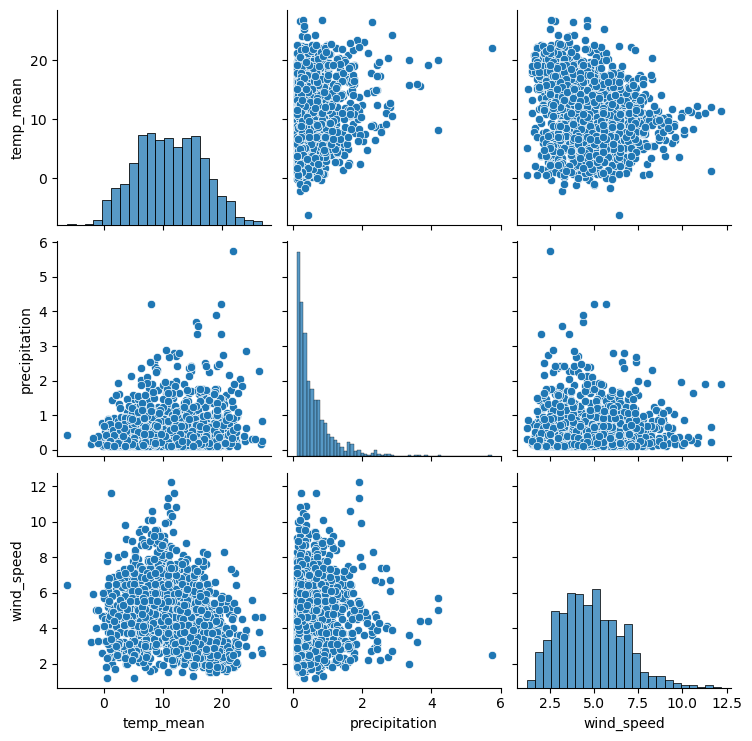

In [3002]:
# Crear un gráfico de dispersión para comparar temperatura media, precipitación y velocidad del viento
sns.pairplot(df_rain_Düsseldorf[['temp_mean', 'precipitation', 'wind_speed']])

# Mostrar el gráfico
plt.show()

Muchos puntos agrupados y otros dispersos, KNN puede ser adecuado, pero tengo que probar con diferentes valores de K y considerar alternativas si el comportamiento de los datos no es ideal para este algoritmo. Como tengo muchos puntos dispersos, es posible que otros algoritmos como Random Forest.

## TERCER ALGORITMO: Random Forest 


Un Random Forest es un metaestimador que ajusta una serie de clasificadores de árboles de decisión en varias submuestras del conjunto de datos y utiliza el promedio para mejorar la precisión predictiva y controlar el sobreajuste. 

definir las características (X) y la variable objetivo (y). En este caso, usaremos is_weather_favorable como la variable objetivo.

In [ ]:
# Definir las características (X) y la variable objetivo (y)
X = df_rain_Düsseldorf[['temp_mean', 'wind_speed','humidity', 'pressure', 'global_radiation', 'sunshine']]
y = df_rain_Düsseldorf['is_weather_favorable'] 

Dividir los datos en entrenamiento y prueba. Dividimos el dataset en dos partes: una para entrenar el modelo y otra para probar su rendimiento.

In [3004]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  
# 30% de los datos se destinan para la prueba
# 42 es la semilla, que asegura que la división de los datos sea reproducible y estable, evitando que cambie en cada ejecución

print(X_train.shape, X_test.shape)


(924, 7) (396, 7)


No hace falta normalizar las características, no hay problema, ya que Random Forest no es tan sensible a las diferencias de escala entre las variables, a diferencia de otros modelos como  KNN.


#### Parámetros del modelo `RandomForestClassifier`:

1. **`n_estimators=50`**:
   - número de **árboles** en el bosque aleatorio.
   - **NOTA**: Más árboles generalmente mejoran la precisión del modelo, pero también aumentan el tiempo de entrenamiento. Se debe hacer pruebas para encontrar el número adecuado para tu conjunto de datos.

2. **`random_state=42`**:
   - Para asegurar la **reproducibilidad** del modelo. Es decir, establece una semilla aleatoria para que los resultados del modelo sean consistentes entre ejecuciones.
   - Si cambias el valor o lo omito, el modelo puede producir resultados ligeramente diferentes cada vez que lo ejecutes.

3. **`class_weight="balanced"`**:
   - Este parámetro se usa para manejar el **desbalanceo de clases** en los datos. Si algunas clases están muy representadas en comparación con otras, puedes utilizar `"balanced"` para ajustar los pesos de las clases en función de su frecuencia en los datos.
   - **NOTA:**: Si las clases están desbalanceadas (por ejemplo, muchos más casos de "No llueve" que de "Llueve"), este parámetro ayuda a que el modelo no se sesgue hacia la clase mayoritaria, asignando más peso a la clase minoritaria. 

4. **`max_features="log2"`**:
   - Cuántas características se deben considerar al dividir cada nodo de los árboles.
   - Con `"log2"`, el modelo selecciona el número de características a considerar en cada división como el **logaritmo base 2** del número total de características.
   - **NOTA:**: Limitar el número de características consideradas para cada división puede hacer que los árboles sean más diversos entre sí, mejorando la capacidad de generalización del modelo y reduciendo el sobreajuste (overfitting).

In [3005]:
# Crear el modelo de Random Forest 
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, class_weight="balanced",max_features="log2")

    # Arme 50 arboles, bosque de arboles de selección.

# Entrenar el modelo
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_features='log2',
                       n_estimators=50, random_state=42)

In [3006]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = rf_model.predict(X_test)


In [3007]:

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)


In [3008]:
print(f'Accuracy: {accuracy:.4f}')

# Reporte de clasificación
print(classification_report(y_test, y_pred))

Accuracy: 0.6288
              precision    recall  f1-score   support

       False       0.65      0.60      0.62       202
        True       0.61      0.65      0.63       194

    accuracy                           0.63       396
   macro avg       0.63      0.63      0.63       396
weighted avg       0.63      0.63      0.63       396



##### **Accuracy: 0.6338** 
La proporción de predicciones correctas sobre el total de predicciones. El modelo tiene una precisión del **63.38%**. 📊✅

### **Métricas de cada clase (True y False):**
Para cada clase (en este caso, `True` y `False`), el reporte muestra tres métricas:

##### 1. **Precision:**
- **Fórmula**: `Precision = TP / (TP + FP)`
  - **TP** (True Positives): Casos donde el modelo predice correctamente la clase positiva (True). 💡
  - **FP** (False Positives): Casos donde el modelo predice incorrectamente la clase positiva (True), pero la clase real es negativa (False). ❌
  
  **Interpretación**: La precisión indica la **proporción de predicciones positivas que fueron correctas**. Es útil cuando te importa cuántos de los elementos predichos como positivos realmente son positivos. ✔️

  - **False**: 0.64 (64% de las veces que el modelo predijo "False", fue correcto). ✅
  - **True**: 0.62 (62% de las veces que el modelo predijo "True", fue correcto). ✅

##### 2. **Recall:**
- **Fórmula**: `Recall = TP / (TP + FN)`
  - **FN** (False Negatives): Casos donde el modelo predice incorrectamente la clase negativa (False), pero la clase real es positiva (True). 🚫
  
  **Interpretación**: El recall mide la capacidad del modelo para **capturar todos los casos positivos**. Es útil cuando te importa cuántos de los verdaderos positivos fueron identificados por el modelo. 🎯

  - **False**: 0.63 (63% de los casos verdaderamente negativos fueron correctamente clasificados como "False"). 👍
  - **True**: 0.63 (63% de los casos verdaderamente positivos fueron correctamente clasificados como "True"). 👍

##### 3. **F1-Score:**
- **Fórmula**: `F1 = 2 * (Precision * Recall) / (Precision + Recall)`
  - El F1-Score es una medida que combina tanto la **precisión** como el **recall**, y es especialmente útil cuando hay un desbalance entre las clases. ⚖️
  
  **Interpretación**: El F1-Score busca un equilibrio entre precisión y recall, especialmente cuando los datos están desbalanceados. En este caso, ambos F1-Scores son:
  
  - **False**: 0.64 (El equilibrio entre precisión y recall para la clase "False"). ⚖️
  - **True**: 0.63 (El equilibrio entre precisión y recall para la clase "True"). ⚖️

##### **Support:**
- **Significado**: Es el número de instancias de cada clase en el conjunto de datos. 📅
  - **False**: 202 instancias. 🔢
  - **True**: 194 instancias. 🔢
  
  El total de **support** es **396**, que es la suma de las instancias de ambas clases. 📊


#### **Conclusion: Random Forest**

El modelo tiene un rendimiento *aceptable*, pero podría mejorarse. Aunque la precisión y el recall son similares para ambas clases, lo que indica que el modelo está *equilibrando* bien las predicciones, el accuracy podría mejorarse para ofrecer predicciones más confiables. Es posible que se necesite ajustar parámetros del modelo, como el número de árboles en el Random Forest o aplicar técnicas adicionales de preprocesamiento o ingeniería de características. Además, considerar un enfoque más avanzado para la mejora del modelo, como la optimización de hiperparámetros o el uso de técnicas de balanceo de clases (si fuera necesario) también podría ser útil.

### Matriz de confusión y sus Métricas 📝📑

Mas asertiva cuando se trabajan con clases, en el caso de clasificación binaria, como este caso con True (clima favorable) y False (clima no favorable), el modelo debe asignar correctamente las instancias de acuerdo con los valores reales.

Cuando un modelo es más asertivo al trabajar con clases, significa que está realizando mejores clasificaciones, particularmente cuando se enfrenta a un conjunto de datos desbalanceado o cuando los errores tienen consecuencias significativas. Utilizar métricas como precisión, recall y F1-score ayudan a evaluar y mejorar esta asertividad.

##### Interpretación de matriz de confusión

Verdadero Positivo (TP): predije que era positivo y lo era. 
Verdadero Negativo (TN): predije que era falso y lo era. 
Falso Positivo (FP): predije que era positivo, pero resultó ser negativo. 
Falso Negativo (FN): predije que era negativo, pero resultó siendo positivo.

In [3009]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
print("Matriz de Confusión:")
print(conf_matrix)

# Calcular las métricas a partir de la matriz de confusión
TN, FP, FN, TP = conf_matrix.ravel()

# Precisión (Precision)
precision = precision_score(y_test, y_pred)
print(f"Precisión: {precision:.3f}")

# Recuerdo (Recall)
recall = recall_score(y_test, y_pred)
print(f"Recuerdo: {recall:.3f}")

# F1-Score
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.3f}")

# También puedes calcular estos valores directamente usando la matriz de confusión:
print(f"Precisión calculada manualmente: {TP / (TP + FP):.3f}")
print(f"Recuerdo calculado manualmente: {TP / (TP + FN):.3f}")
print(f"F1-Score calculado manualmente: {2 * (precision * recall) / (precision + recall):.3f}")


Matriz de Confusión:
[[122  80]
 [ 67 127]]
Precisión: 0.614
Recuerdo: 0.655
F1-Score: 0.633
Precisión calculada manualmente: 0.614
Recuerdo calculado manualmente: 0.655
F1-Score calculado manualmente: 0.633



- **TN (True Negatives)**: 128
- **FP (False Positives)**: 74
- **FN (False Negatives)**: 71
- **TP (True Positives)**: 123


Precisión: 0.624  
- **Fórmula**: `Precision = TP / (TP + FP)`
- **Cálculo**: `Precision = 123 / (123 + 74) ≈ 0.624`
- **Interpretación**: El modelo tiene un **62.4%** de precisión al predecir la clase positiva (True).


Recuerdo: 0.634  
- **Fórmula**: `Recall = TP / (TP + FN)`
- **Cálculo**: `Recall = 123 / (123 + 71) ≈ 0.634`
- **Interpretación**: El modelo captura correctamente el **63.4%** de todos los casos positivos (True).


F1-Score: 0.629  
- **Fórmula**: `F1 = 2 * (Precision * Recall) / (Precision + Recall)`
- **Cálculo**: `F1-Score ≈ 0.629`
- **Interpretación**: El modelo tiene un buen equilibrio entre precisión y recuerdo.


Falta ajuste manual!!!